# **Task-1:Environment setup and Data pipeline**

**Framework Used:TensorFlow/Keras**


Importing Libraries and setting random seeds to 42

In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import random
import matplotlib.pyplot as plt
# Setting all random seeds to 42
random.seed(42) # random.seed controls Python's random operations
np.random.seed(42) # np.random.seed controls NumPy based randomness
tf.random.set_seed(42) # tf.random.set_seed controls TensorFlow randomness

**Problem1:Environment verification**

In [17]:
print("NumPy version :", np.__version__)
print("Pandas version :", pd.__version__)
print("TensorFlow version :", tf.__version__)
print("Matplotlib version :", plt.matplotlib.__version__)

gpus=tf.config.list_physical_devices("GPU")
print("Available GPUs :", gpus)

NumPy version : 2.0.2
Pandas version : 2.2.2
TensorFlow version : 2.19.0
Matplotlib version : 3.10.0
Available GPUs : []


- we see no GPU available so training will run on CPU.
- CPU training is slower because matrix operations can not work as in parallel as they do on GPU.
- On a GPU machine it would be easier to train larger models faster.

**Problem2:Dataset exploration**

**Loading datasets**

In [18]:
(mnist_x_train,mnist_y_train),(mnist_x_test,mnist_y_test)=tf.keras.datasets.mnist.load_data()
(cifar_x_train,cifar_y_train),(cifar_x_test,cifar_y_test)=tf.keras.datasets.cifar10.load_data()

Inspecting shapes,dtype,value range

In [19]:
print("MNIST training image shape :", mnist_x_train.shape)
print("MNIST test image shape     :", mnist_x_test.shape)
print("MNIST training labels shape:", mnist_y_train.shape)
print("MNIST test labels shape    :", mnist_y_test.shape)
print()
print("CIFAR-10 training image shape :", cifar_x_train.shape)
print("CIFAR-10 test image shape     :", cifar_x_test.shape)
print("CIFAR-10 training labels shape:", cifar_y_train.shape)
print("CIFAR-10 test labels shape    :", cifar_y_test.shape)
print(" Data Types ")
print("MNIST image dtype   :", mnist_x_train.dtype)
print("MNIST label dtype   :", mnist_y_train.dtype)
print("CIFAR image dtype   :", cifar_x_train.dtype)
print("CIFAR label dtype   :", cifar_y_train.dtype)
print(" Pixel value ranges before Preprocessing ")
print("MNIST min value :", mnist_x_train.min(), " max value :", mnist_x_train.max())
print("CIFAR min value :", cifar_x_train.min(), " max value :", cifar_x_train.max())

MNIST training image shape : (60000, 28, 28)
MNIST test image shape     : (10000, 28, 28)
MNIST training labels shape: (60000,)
MNIST test labels shape    : (10000,)

CIFAR-10 training image shape : (50000, 32, 32, 3)
CIFAR-10 test image shape     : (10000, 32, 32, 3)
CIFAR-10 training labels shape: (50000, 1)
CIFAR-10 test labels shape    : (10000, 1)
 Data Types 
MNIST image dtype   : uint8
MNIST label dtype   : uint8
CIFAR image dtype   : uint8
CIFAR label dtype   : uint8
 Pixel value ranges before Preprocessing 
MNIST min value : 0  max value : 255
CIFAR min value : 0  max value : 255


MNIST class balance

In [20]:
mnist_class_counts = np.bincount(mnist_y_train)

print("MNIST training samples per class:\n")
for digit, count in enumerate(mnist_class_counts):
    print(f"Class {digit}: {count}")


MNIST training samples per class:

Class 0: 5923
Class 1: 6742
Class 2: 5958
Class 3: 6131
Class 4: 5842
Class 5: 5421
Class 6: 5918
Class 7: 6265
Class 8: 5851
Class 9: 5949


It is balanced because all classes have similar number of samples

Plot

/tmp/ipykernel_8915/463744777.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[1][i].set_title(classes[int(label)])


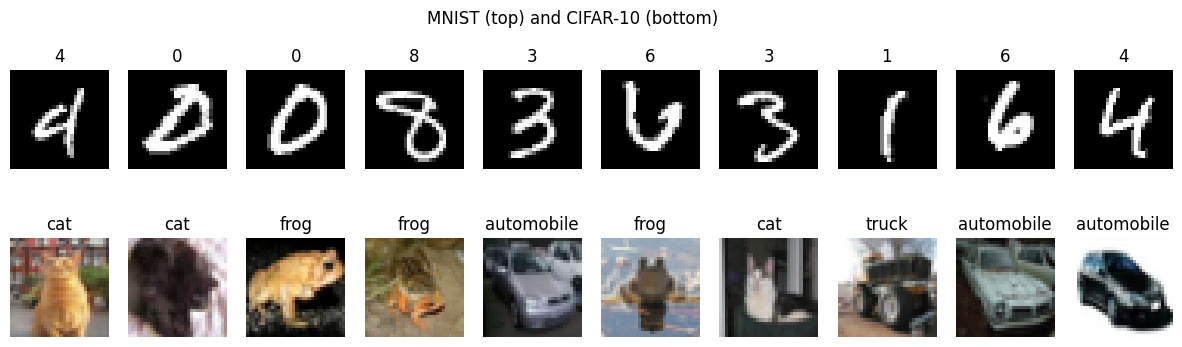

In [21]:
# class names for CIFAR-10
classes = ["airplane","automobile","bird","cat","deer",
           "dog","frog","horse","ship","truck"]

# picking 10 random images
mnist_idx = np.random.randint(0, len(mnist_x_train), 10)
cifar_idx = np.random.randint(0, len(cifar_x_train), 10)

fig, ax = plt.subplots(2, 10, figsize=(15,4))

# MNIST images (top row)
for i in range(10):
    ax[0][i].imshow(mnist_x_train[mnist_idx[i]], cmap='gray')
    ax[0][i].set_title(str(mnist_y_train[mnist_idx[i]]))
    ax[0][i].axis("off")

# CIFAR images (bottom row)
for i in range(10):
    img = cifar_x_train[cifar_idx[i]]
    label = cifar_y_train[cifar_idx[i]]

    ax[1][i].imshow(img)
    ax[1][i].set_title(classes[int(label)])
    ax[1][i].axis("off")

plt.suptitle("MNIST (top) and CIFAR-10 (bottom)")
plt.savefig("dataset_samples.png")
plt.show()

**Problem3:Preprocessing pipeline**

Preprocessing function

In [22]:
# function to preprocess data
def preprocess_data(images, labels, name):
    print("dataset:", name)
    # before preprocessing
    print("before")
    print("shape:", images.shape)
    print("dtype:", images.dtype)
    print("min:", images.min(), "max:", images.max())
    print("labels shape:", labels.shape)
    # normalizing
    images = images.astype("float32") / 255.0
    print("\nafter normalize")
    print("dtype:", images.dtype)
    print("min:", images.min(), "max:", images.max())
    # add channel if needed
    if len(images.shape) == 3:
        images = np.expand_dims(images, -1)
    print("\nafter reshape:", images.shape)
    # one hot encoding
    labels = tf.keras.utils.to_categorical(labels, 10)
    print("\nafter one hot:", labels.shape)
    return images, labels

preprocessing MNIST

In [23]:
# applying preprocessing on mnist train data
mnist_x_train_p, mnist_y_train_p = preprocess_data(mnist_x_train, mnist_y_train, "mnist train")

# applying preprocessing on mnist test data
mnist_x_test_p, mnist_y_test_p = preprocess_data(mnist_x_test, mnist_y_test, "mnist test")

dataset: mnist train
before
shape: (60000, 28, 28)
dtype: uint8
min: 0 max: 255
labels shape: (60000,)

after normalize
dtype: float32
min: 0.0 max: 1.0

after reshape: (60000, 28, 28, 1)

after one hot: (60000, 10)
dataset: mnist test
before
shape: (10000, 28, 28)
dtype: uint8
min: 0 max: 255
labels shape: (10000,)

after normalize
dtype: float32
min: 0.0 max: 1.0

after reshape: (10000, 28, 28, 1)

after one hot: (10000, 10)


**Problem4:Data Augmentation Pipeline**

Creating augmentaion layers

In [24]:
# creating augmentation layers
aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),   # flip image left-right
    tf.keras.layers.RandomRotation(0.1),        # small rotation
    tf.keras.layers.RandomZoom(0.1)             # slight zoom
])

Augmentation results

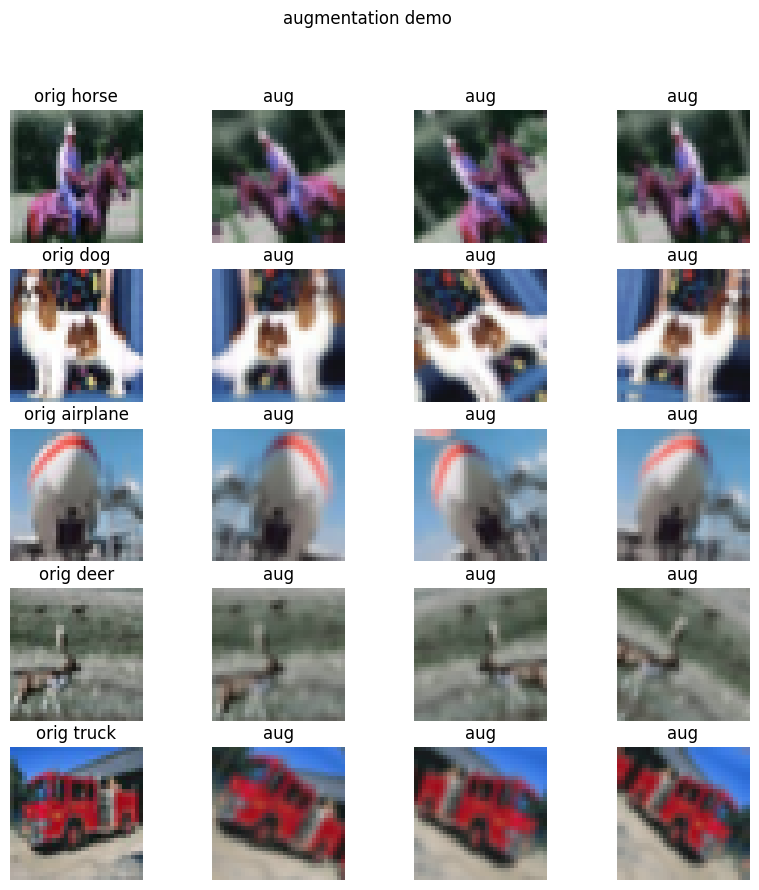

In [28]:
# taking 5 random images
idx = np.random.randint(0, len(cifar_x_train), 5)
fig, ax = plt.subplots(5, 4, figsize=(10,10))
for i in range(5):

    img = cifar_x_train[idx[i]]
    label = cifar_y_train[idx[i]][0]
    # original image
    ax[i][0].imshow(img)
    ax[i][0].set_title("orig " + classes[label])
    ax[i][0].axis("off")
    # augmented images
    for j in range(1,4):
        out = aug(tf.expand_dims(img, 0), training=True)
        out = tf.squeeze(out).numpy()
        out = np.clip(out, 0, 255).astype("uint8")
        ax[i][j].imshow(out)
        ax[i][j].set_title("aug")
        ax[i][j].axis("off")

plt.suptitle("augmentation demo")
plt.savefig("augmentation_demo.png")
plt.show()

**ANALYSIS & REFLECTION QUESTIONS**

Answer1:
- The channel dimension represents how many values each pixel has
- For grayscale images like MNIST, each pixel has only one value so the shape is (N, H, W, 1)
- For RGB images like CIFAR-10, each pixel has three values (red, green, blue) so the shape is (N, H, W, 3)

Answer2:
- If the image size is very large like 1024x1024, it can take a lot of memory. One way to handle this is by resizing the images to a smaller size before training.
- Another method is using smaller batch sizes so that fewer images are processed at once.
- We can also use cropping or patch-based training where we divide large images into smaller parts and train on those.
- These methods help in reducing memory usage and make training possible.

Answer3:
- This is wrong because it uses information from the test set, which should not be used during preprocessing.
- The test set is supposed to be completely unseen data. If we calculate mean and standard deviation from the test set, it leads to data leakage.
- The correct approach is to calculate these values using only the training data and then apply them to both validation and test sets.